In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LABEL_MAP   = {'Low': 0, 'Medium': 1, 'High': 2}
INV_LABEL   = {0: 'Low', 1: 'Medium', 2: 'High'}
WINDOW_SIZE = 30
N_FEATURES  = 8
OUT_DIR     = '/kaggle/working'

FEATURE_NAMES = [
    'l_knee_angle', 'r_knee_angle', 'l_hip_angle', 'r_hip_angle',
    'trunk_lean', 'asymmetry', 'l_knee_vel', 'r_knee_vel'
]

In [2]:
class ACLRiskLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.attention = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_scores = self.attention(lstm_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        context = (lstm_out * attn_weights).sum(dim=1)
        return self.classifier(context)

CKPT_PATH = '/kaggle/input/datasets/haruxo/input-6f/acl_risk_model_phase6.pt'

model = ACLRiskLSTM().to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print("Checkpoint loaded.")

Checkpoint loaded.


In [3]:
VAL_PKL = '/kaggle/input/datasets/haruxo/input-6f/val_samples.pkl'

with open(VAL_PKL, 'rb') as f:
    val_samples = pickle.load(f)

print(f"Val samples: {len(val_samples)}")

# Dataset class — same as Phase 6
class ACLDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        x = torch.tensor(s['features'], dtype=torch.float32)   # (30, 8)
        y = LABEL_MAP[s['label']]
        return x, y

val_dataset = ACLDataset(val_samples)
val_loader  = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
print(f"Val batches: {len(val_loader)}")

Val samples: 76832
Val batches: 1201


In [4]:
def enable_dropout(model):
    """
    Sets model to eval mode globally, then re-enables only nn.Dropout layers.
    This keeps BN/LSTM/Linear in eval mode while activating stochastic dropout.
    """
    model.eval()
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

In [5]:
enable_dropout(model)
dropout_train = sum(1 for m in model.modules()
                    if isinstance(m, nn.Dropout) and m.training)
lstm_eval     = sum(1 for m in model.modules()
                    if isinstance(m, nn.LSTM) and not m.training)
print(f"Dropout layers in train mode : {dropout_train}")   # Should be > 0
print(f"LSTM layers in eval mode     : {lstm_eval}")       # Should be > 0

Dropout layers in train mode : 2
LSTM layers in eval mode     : 1


In [6]:
def mc_dropout_predict(model, x_tensor, n_passes=50, temperature=2.5):
    """
    Temperature > 1 softens the softmax, spreading probability mass and
    producing meaningful entropy values from an overconfident model.
    T=2.5 is a standard starting point for post-hoc calibration.
    """
    enable_dropout(model)
    all_probs = []

    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(x_tensor)                            # (B, 3)
            # Apply temperature scaling before softmax
            probs  = torch.softmax(logits / temperature, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs  = np.stack(all_probs, axis=0)                    # (50, B, 3)
    mean_probs = all_probs.mean(axis=0)                         # (B, 3)
    std_probs  = all_probs.std(axis=0)                          # (B, 3)

    eps     = 1e-8
    entropy = -np.sum(mean_probs * np.log(mean_probs + eps), axis=1)

    return mean_probs, std_probs, entropy

In [7]:
all_true       = []
all_mean_probs = []
all_entropy    = []

print(f"Running MC Dropout — 50 passes over {len(val_loader)} batches...")
print("This will take 20–40 minutes. Do not interrupt.\n")

for batch_idx, (x_batch, y_batch) in enumerate(val_loader):
    x_batch = x_batch.to(DEVICE)
    
    mean_p, _, ent = mc_dropout_predict(model, x_batch, n_passes=50)
    
    all_true.append(y_batch.numpy())
    all_mean_probs.append(mean_p)
    all_entropy.append(ent)
    
    if (batch_idx + 1) % 10 == 0:
        print(f"  Batch {batch_idx+1}/{len(val_loader)} done...")

all_true       = np.concatenate(all_true,       axis=0)   # (N,)
all_mean_probs = np.concatenate(all_mean_probs, axis=0)   # (N, 3)
all_entropy    = np.concatenate(all_entropy,    axis=0)   # (N,)
all_pred       = np.argmax(all_mean_probs, axis=1)        # (N,)

print(f"\nDone. Total samples processed: {len(all_true)}")

# Save raw results immediately as safety net
np.save(os.path.join(OUT_DIR, 'mc_entropy_raw.npy'),    all_entropy)
np.save(os.path.join(OUT_DIR, 'mc_mean_probs_raw.npy'), all_mean_probs)
print("Raw arrays saved.")

Running MC Dropout — 50 passes over 1201 batches...
This will take 20–40 minutes. Do not interrupt.

  Batch 10/1201 done...
  Batch 20/1201 done...
  Batch 30/1201 done...
  Batch 40/1201 done...
  Batch 50/1201 done...
  Batch 60/1201 done...
  Batch 70/1201 done...
  Batch 80/1201 done...
  Batch 90/1201 done...
  Batch 100/1201 done...
  Batch 110/1201 done...
  Batch 120/1201 done...
  Batch 130/1201 done...
  Batch 140/1201 done...
  Batch 150/1201 done...
  Batch 160/1201 done...
  Batch 170/1201 done...
  Batch 180/1201 done...
  Batch 190/1201 done...
  Batch 200/1201 done...
  Batch 210/1201 done...
  Batch 220/1201 done...
  Batch 230/1201 done...
  Batch 240/1201 done...
  Batch 250/1201 done...
  Batch 260/1201 done...
  Batch 270/1201 done...
  Batch 280/1201 done...
  Batch 290/1201 done...
  Batch 300/1201 done...
  Batch 310/1201 done...
  Batch 320/1201 done...
  Batch 330/1201 done...
  Batch 340/1201 done...
  Batch 350/1201 done...
  Batch 360/1201 done...
  Batch 

In [8]:
# 85th percentile threshold — top 15% most uncertain are flagged
entropy_threshold = np.percentile(all_entropy, 85)
flagged           = (all_entropy > entropy_threshold).astype(int)

n_certain   = int((flagged == 0).sum())
n_uncertain = int((flagged == 1).sum())

print(f"Entropy threshold (85th pct) : {entropy_threshold:.4f}")
print(f"Certain samples              : {n_certain}  ({100*n_certain/len(flagged):.1f}%)")
print(f"Uncertain samples (flagged)  : {n_uncertain}  ({100*n_uncertain/len(flagged):.1f}%)")

Entropy threshold (85th pct) : 0.0416
Certain samples              : 65307  (85.0%)
Uncertain samples (flagged)  : 11525  (15.0%)


In [9]:
certain_mask   = flagged == 0
uncertain_mask = flagged == 1

f1_certain   = f1_score(all_true[certain_mask],   all_pred[certain_mask],
                        average='macro', zero_division=0)
f1_uncertain = f1_score(all_true[uncertain_mask], all_pred[uncertain_mask],
                        average='macro', zero_division=0)
f1_overall   = f1_score(all_true, all_pred, average='macro', zero_division=0)

print("\n" + "=" * 48)
print("CERTAINTY vs UNCERTAINTY — F1 COMPARISON")
print("=" * 48)
print(f"  Overall  Macro F1  : {f1_overall:.4f}")
print(f"  Certain  Macro F1  : {f1_certain:.4f}  (bottom 85% entropy)")
print(f"  Uncertain Macro F1 : {f1_uncertain:.4f}  (top 15% entropy — flagged)")
print("=" * 48)
print(f"\n  >> F1 gap: {f1_certain - f1_uncertain:.4f}  —  "
      f"model is {'significantly' if f1_certain - f1_uncertain > 0.05 else 'marginally'} "
      f"more reliable on certain predictions")


CERTAINTY vs UNCERTAINTY — F1 COMPARISON
  Overall  Macro F1  : 0.4329
  Certain  Macro F1  : 0.4571  (bottom 85% entropy)
  Uncertain Macro F1 : 0.2986  (top 15% entropy — flagged)

  >> F1 gap: 0.1585  —  model is significantly more reliable on certain predictions


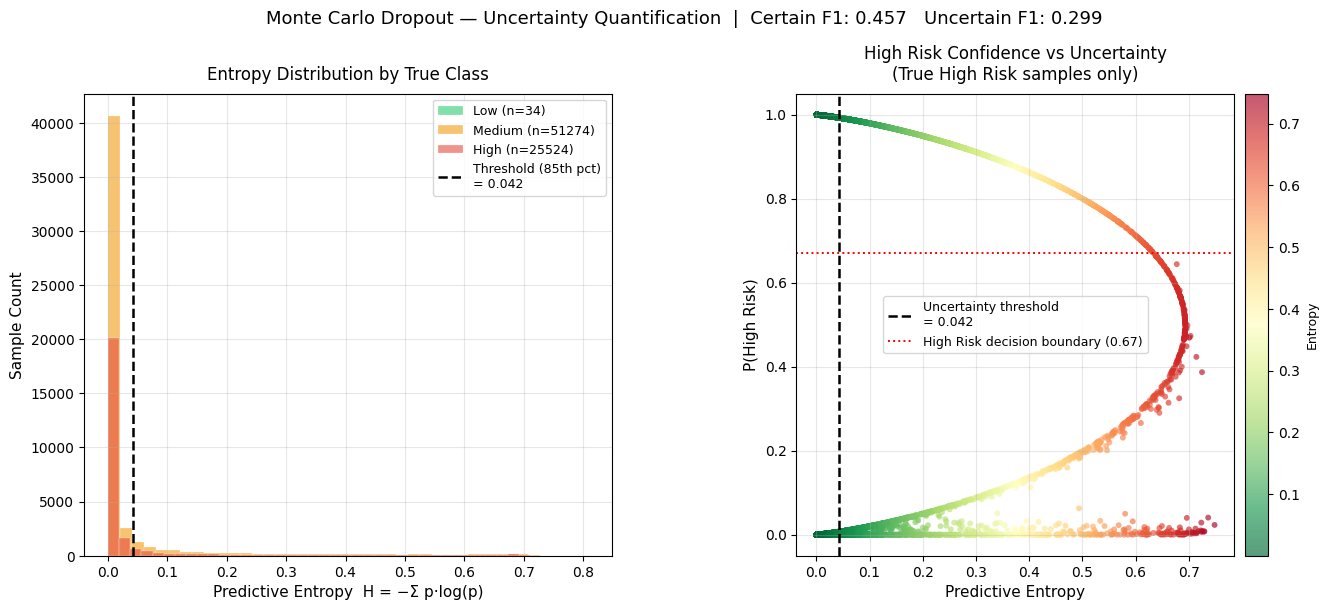

Saved: mc_dropout_uncertainty.png


In [10]:
true_label_names = np.array([INV_LABEL[i] for i in all_true])
high_risk_prob   = all_mean_probs[:, 2]   # P(High Risk) per sample

fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

# ── Panel 1: Entropy Distribution by True Class ─────────────────────────────
ax1    = fig.add_subplot(gs[0])
colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for cls in ['Low', 'Medium', 'High']:
    mask = true_label_names == cls
    ax1.hist(
        all_entropy[mask],
        bins=40, alpha=0.6,
        label=f'{cls} (n={mask.sum()})',
        color=colors[cls], edgecolor='white', linewidth=0.3
    )

ax1.axvline(entropy_threshold, color='black', linestyle='--', lw=1.8,
            label=f'Threshold (85th pct)\n= {entropy_threshold:.3f}')
ax1.set_xlabel('Predictive Entropy  H = −Σ p·log(p)', fontsize=11)
ax1.set_ylabel('Sample Count', fontsize=11)
ax1.set_title('Entropy Distribution by True Class', fontsize=12, pad=10)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Panel 2: High Risk Probability vs Entropy (High Risk true samples only) ──
ax2       = fig.add_subplot(gs[1])
high_mask = true_label_names == 'High'

sc = ax2.scatter(
    all_entropy[high_mask],
    high_risk_prob[high_mask],
    c=all_entropy[high_mask],
    cmap='RdYlGn_r',
    alpha=0.65, s=18, edgecolors='none'
)
ax2.axvline(entropy_threshold, color='black', linestyle='--', lw=1.8,
            label=f'Uncertainty threshold\n= {entropy_threshold:.3f}')
ax2.axhline(0.67, color='red', linestyle=':', lw=1.4,
            label='High Risk decision boundary (0.67)')

ax2.set_xlabel('Predictive Entropy', fontsize=11)
ax2.set_ylabel('P(High Risk)', fontsize=11)
ax2.set_title('High Risk Confidence vs Uncertainty\n(True High Risk samples only)',
              fontsize=12, pad=10)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=ax2, pad=0.02)
cbar.set_label('Entropy', fontsize=9)

fig.suptitle(
    f'Monte Carlo Dropout — Uncertainty Quantification  |  '
    f'Certain F1: {f1_certain:.3f}   Uncertain F1: {f1_uncertain:.3f}',
    fontsize=13, y=1.02
)

plt.savefig(os.path.join(OUT_DIR, 'mc_dropout_uncertainty.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mc_dropout_uncertainty.png")

In [11]:
uncertainty_df = pd.DataFrame({
    'true_label'     : [INV_LABEL[i] for i in all_true],
    'pred_label'     : [INV_LABEL[i] for i in all_pred],
    'high_risk_prob' : np.round(high_risk_prob, 5),
    'entropy'        : np.round(all_entropy,    5),
    'flagged'        : flagged
})

uncertainty_df.to_csv(os.path.join(OUT_DIR, 'uncertainty_predictions.csv'), index=False)

print("Saved: uncertainty_predictions.csv")
print(f"\nSample rows:")
print(uncertainty_df.head(10).to_string(index=False))

Saved: uncertainty_predictions.csv

Sample rows:
true_label pred_label  high_risk_prob  entropy  flagged
    Medium     Medium         0.00003  0.00046        0
      High        Low         0.00000  0.00307        0
      High       High         0.99986  0.00138        0
      High        Low         0.00000  0.15358        1
    Medium       High         0.98498  0.07798        1
      High       High         0.99933  0.00554        0
    Medium     Medium         0.00000  0.00002        0
    Medium       High         0.99985  0.00147        0
      High       High         0.99914  0.00695        0
    Medium     Medium         0.00003  0.00034        0


In [12]:
outputs_6f = [
    'mc_dropout_uncertainty.png',
    'uncertainty_predictions.csv',
    'mc_entropy_raw.npy',
    'mc_mean_probs_raw.npy'
]

print("=" * 48)
print("PHASE 6F OUTPUT FILES")
print("=" * 48)
for fname in outputs_6f:
    fpath = os.path.join(OUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {fname:<40}  {size_kb:>8.1f} KB")
    else:
        print(f"  {fname:<40}  NOT FOUND")

print(f"\nEntropy threshold : {entropy_threshold:.4f}")
print(f"Certain F1        : {f1_certain:.4f}")
print(f"Uncertain F1      : {f1_uncertain:.4f}")
print(f"F1 gap            : {f1_certain - f1_uncertain:.4f}")
print("\nPhase 6F complete.")

PHASE 6F OUTPUT FILES
  mc_dropout_uncertainty.png                   177.9 KB
  uncertainty_predictions.csv                 2135.0 KB
  mc_entropy_raw.npy                           300.2 KB
  mc_mean_probs_raw.npy                        900.5 KB

Entropy threshold : 0.0416
Certain F1        : 0.4571
Uncertain F1      : 0.2986
F1 gap            : 0.1585

Phase 6F complete.
